# 1. Environment Setup

Import all necessary libraries including pandas, numpy, scikit-learn for data processing, machine learning, and visualization. Set random seeds for reproducibility.

In [12]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, MinMaxScaler

# Đặt seed để đảm bảo nhất quán giữa các lần chạy
os.environ["PYTHONHASHSEED"] = "42"
np.random.seed(42)
random.seed(42)
print("Seed: 42")

Seed: 42


# 2. Data Processing

## 2.0 Dataset

### Overview
The Cleveland Heart Disease dataset contains 14 clinical features used to predict the presence of heart disease in patients. These are standard measurements taken during cardiac health assessments.<br>
Source: https://www.kaggle.com/datasets/ritwikb3/heart-disease-cleveland
### Feature Descriptions

| Feature | Description |
|---------|-------------|
| **age** | Age in years |
| **sex** | Sex (1 = male; 0 = female) |
| **cp** | Chest pain type: 1 = typical angina; 2 = atypical angina; 3 = non-anginal pain; 4 = asymptomatic |
| **trestbps** | Resting blood pressure (mm Hg on hospital admission) |
| **chol** | Serum cholesterol in mg/dL |
| **fbs** | Fasting blood sugar > 120 mg/dL (1 = true; 0 = false) |
| **restecg** | Resting electrocardiographic results: 0 = normal; 1 = ST-T wave abnormality; 2 = probable/definite left ventricular hypertrophy |
| **thalach** | Maximum heart rate achieved |
| **exang** | Exercise-induced angina (1 = yes; 0 = no) |
| **oldpeak** | ST depression induced by exercise relative to rest |
| **slope** | The slope of the peak exercise ST segment: 1 = upsloping; 2 = flat; 3 = downsloping |
| **ca** | Number of major vessels (0-3) colored by fluoroscopy |
| **thal** | Thalassemia: 3 = normal; 6 = fixed defect; 7 = reversible defect |
| **target** | Diagnosis of heart disease: 0 = no disease; 1 = disease present |

### Summary
These 13 features are clinical measurements commonly used by cardiologists to assess heart disease risk. The combination of demographic, symptom-related, and test-based features enables comprehensive cardiac health assessment for predictive modeling.

## 2.1 Data Processing 

Download the Cleveland heart disease dataset from Google Drive.

In [13]:
!gdown 16HPyuXWXPptt5g3xvS_kR_wXAfjpR1Ju

Downloading...
From: https://drive.google.com/uc?id=16HPyuXWXPptt5g3xvS_kR_wXAfjpR1Ju
To: /content/cleveland.csv
100% 10.9k/10.9k [00:00<00:00, 22.9MB/s]


Load and preview the raw data to understand its structure.

In [14]:
test=pd.read_csv("cleveland.csv")
test.head(10)

,63,1,1.1,145,233,1.2,2,150,0,2.3,3,0.1,6,0.2
0,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
1,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
2,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
3,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
4,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
5,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,3
6,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
7,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,2
8,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1
9,57,1,4,140,192,0,0,148,0,0.4,2,0.0,6.0,0


Assign column names to the dataset and convert the target variable to binary (0 or 1) where 1 indicates presence of heart disease.

In [15]:
COLUMNS = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 
    'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 
    'ca', 'thal', 'target'
]
PATH="cleveland.csv"
raw_df = pd.read_csv(PATH, names=COLUMNS)
raw_df["target"] = raw_df["target"].apply(lambda x: 1 if x > 0 else 0)
raw_df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
5,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
6,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,1
7,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
8,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,1
9,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1


Separate features into numeric and categorical columns for appropriate preprocessing.

In [16]:
FEATURES=[col for col in raw_df.columns if col != "target"]
numeric_cols=[]
categorical_cols=[]
for col in FEATURES:
    unique_col=raw_df[col].nunique()
    if unique_col>10:
        numeric_cols.append(col)
    else:
        categorical_cols.append(col)
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


# 3. EDA

## 3.0 Target Quick Check 

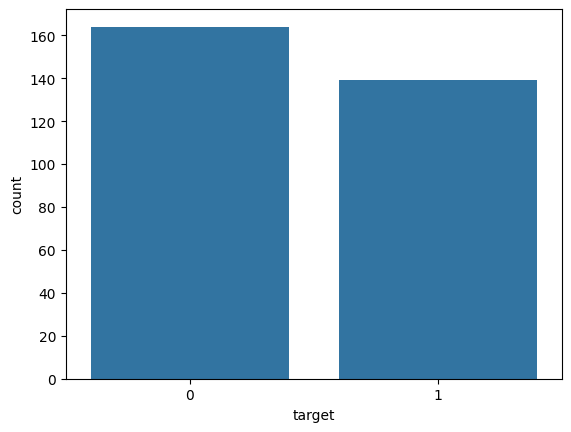

In [24]:
# Create countplot
ax = sns.countplot(x='target', data=raw_df)


### Key Insights
✅ **Well-Balanced Dataset** - The classes are nearly evenly distributed, indicating minimal class imbalance.

✅ **Model Training Advantage** - With balanced classes, we can train ML models without special handling techniques like oversampling, undersampling, or class weight adjustments.

✅ **Fair Evaluation** - The balanced distribution ensures that accuracy and other metrics will be meaningful without being skewed by class prevalence.

## 3.1 Numeric Features

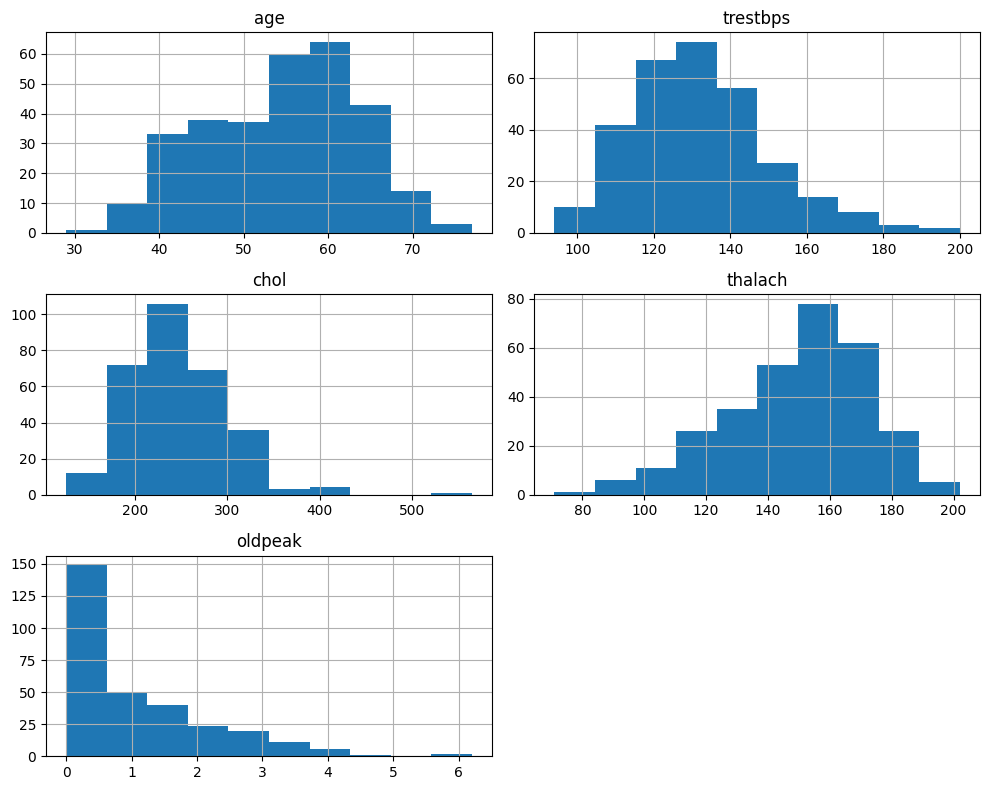

In [18]:
# Plot histograms for numerical columns
raw_df[numeric_cols].hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

### Insights:
* **Age** - Normal distribution, peaks at 55-60 years (middle-aged/older adults)
* **Trestbps** - Normal distribution, centered around 120-130 mm Hg
* **Chol** - Right-skewed with outliers, peaks at 200-250 mg/dL
* **thalach** - thalach appears approximately normally distributed, with a bell-shaped pattern centered around 150–165.
* **Oldpeak** - Heavily right-skewed with >140 patients at 0 (healthy), outliers suggest disease


## 3.2 Categorical Features

In [20]:
categorical_cols

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

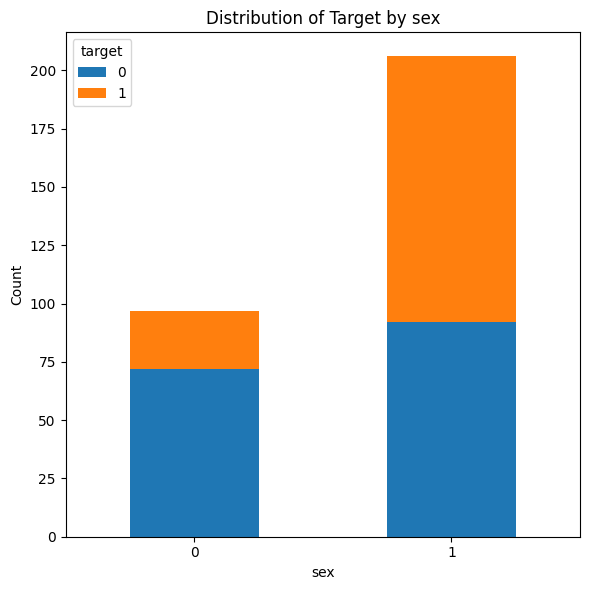

In [21]:
col="sex"
plt.figure(figsize=(6, 6))
raw_df.groupby([col, 'target']).size().unstack().plot(kind='bar', stacked=True, ax=plt.gca())
plt.title(f'Distribution of Target by {col}')
plt.xlabel(col)
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insights**:
